# IMDb Movie Ratings Analysis

### Analyzing Movie Ratings, Genres and Top Rated Movies

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load dataset

In [2]:
df = pd.read_csv("movies.csv")

df

,Movie URL,Title,Poster,Release Year,Length in Min,IMDB Rating,Rating Count,Plot,Directors,Writers,Stars,Genres
0,https://www.imdb.com/title/tt0001892/?ref_=sr_t_3,Den sorte drøm,https://m.media-amazon.com/images/M/MV5BZjg0Yj...,1911.0,53.0,5.8,265.0,Two men of high rank are both wooing the beaut...,Urban Gad|,Urban Gad|Gebhard Schätzler-Perasini|,Asta Nielsen|Valdemar Psilander|Gunnar Helseng...,Drama
1,https://www.imdb.com/title/tt0001964/?ref_=sr_t_6,Die Verräterin,https://m.media-amazon.com/images/M/MV5BNjI2Nj...,1911.0,48.0,5.9,100.0,A woman betrays the regiment location in which...,Urban Gad,Erich Zeiske|,Asta Nielsen|Max Obal|Robert Valberg,Drama
2,https://www.imdb.com/title/tt0002101/?ref_=sr_t_1,Cleopatra,https://m.media-amazon.com/images/M/MV5BZTcyMG...,1912.0,100.0,5.1,620.0,The fabled queen of Egypt's affair with Roman ...,Charles L. Gaskill|,Victorien Sardou|Charles L. Gaskill|,Helen Gardner|Pearl Sindelar|Miss Fielding,Drama|History
3,https://www.imdb.com/title/tt0002130/?ref_=sr_t_1,L'Inferno,https://m.media-amazon.com/images/M/MV5BMzY0NT...,1911.0,71.0,7.0,3500.0,Loosely adapted from Dante's Divine Comedy and...,Francesco Bertolini|Adolfo Padovan|Giuseppe de...,Dante Alighieri|,Salvatore Papa|Arturo Pirovano|Giuseppe de Lig...,Adventure|Drama|Fantasy
4,https://www.imdb.com/title/tt0002186/?ref_=sr_t_6,Den flyvende cirkus,https://m.media-amazon.com/images/M/MV5BZTljZD...,1912.0,46.0,6.4,145.0,The Flying Circus was the largest traveling ar...,Alfred Lind|,Carl Otto Dumreicher|Alfred Lind|,Rasmus Ottesen|Emilie Otterdahl|Lili Beck,Drama
...,...,...,...,...,...,...,...,...,...,...,...,...
126686,https://www.imdb.com/title/tt2787570/?ref_=sr_...,Den allvarsamma leken,https://m.media-amazon.com/images/M/MV5BODRjOW...,2016.0,115.0,6.4,1400.0,"An adaptation of Hjalmar Söderberg's novel ""Th...",Pernilla August|,Hjalmar Söderberg|Lone Scherfig|Hjalmar Söderb...,Sverrir Gudnason|Karin Franz Körlof|Liv Mjönes,Drama|Romance
126687,https://www.imdb.com/title/tt27876411/?ref_=sr...,Pan Samochodzik i templariusze,https://m.media-amazon.com/images/M/MV5BNGY1Nz...,2023.0,110.0,4.3,1300.0,When an art historian finds an ancient Templar...,Antoni Nykowski|,Bartosz Sztybor|Antoni Nykowski|Zbigniew Niena...,Mateusz Janicki|Sandra Drzymalska|Maria Debska,Adventure|Drama|Family
126688,https://www.imdb.com/title/tt2787824/?ref_=sr_...,Goal of the Dead,https://m.media-amazon.com/images/M/MV5BMjcxNz...,2014.0,140.0,5.5,1600.0,A professional football team arrives at their ...,Thierry Poiraud|Benjamin Rocher|,Tristan Schulmann|Nicolas Peufaillit|Quoc Dang...,Alban Lenoir|Charlie Bruneau|Tiphaine Daviot,Comedy|Horror
126689,https://www.imdb.com/title/tt2787834/?ref_=sr_...,Muito Além do Peso,https://m.media-amazon.com/images/M/MV5BMTkyNT...,2012.0,83.0,8.0,267.0,"From Brazil to Kuwait, the levels of childhood...",Estela Renner|,NaN,NaN,Documentary


## 3. Check first 10 rows

In [3]:
df.head(10)

,Movie URL,Title,Poster,Release Year,Length in Min,IMDB Rating,Rating Count,Plot,Directors,Writers,Stars,Genres
0,https://www.imdb.com/title/tt0001892/?ref_=sr_t_3,Den sorte drøm,https://m.media-amazon.com/images/M/MV5BZjg0Yj...,1911.0,53.0,5.8,265.0,Two men of high rank are both wooing the beaut...,Urban Gad|,Urban Gad|Gebhard Schätzler-Perasini|,Asta Nielsen|Valdemar Psilander|Gunnar Helseng...,Drama
1,https://www.imdb.com/title/tt0001964/?ref_=sr_t_6,Die Verräterin,https://m.media-amazon.com/images/M/MV5BNjI2Nj...,1911.0,48.0,5.9,100.0,A woman betrays the regiment location in which...,Urban Gad,Erich Zeiske|,Asta Nielsen|Max Obal|Robert Valberg,Drama
2,https://www.imdb.com/title/tt0002101/?ref_=sr_t_1,Cleopatra,https://m.media-amazon.com/images/M/MV5BZTcyMG...,1912.0,100.0,5.1,620.0,The fabled queen of Egypt's affair with Roman ...,Charles L. Gaskill|,Victorien Sardou|Charles L. Gaskill|,Helen Gardner|Pearl Sindelar|Miss Fielding,Drama|History
3,https://www.imdb.com/title/tt0002130/?ref_=sr_t_1,L'Inferno,https://m.media-amazon.com/images/M/MV5BMzY0NT...,1911.0,71.0,7.0,3500.0,Loosely adapted from Dante's Divine Comedy and...,Francesco Bertolini|Adolfo Padovan|Giuseppe de...,Dante Alighieri|,Salvatore Papa|Arturo Pirovano|Giuseppe de Lig...,Adventure|Drama|Fantasy
4,https://www.imdb.com/title/tt0002186/?ref_=sr_t_6,Den flyvende cirkus,https://m.media-amazon.com/images/M/MV5BZTljZD...,1912.0,46.0,6.4,145.0,The Flying Circus was the largest traveling ar...,Alfred Lind|,Carl Otto Dumreicher|Alfred Lind|,Rasmus Ottesen|Emilie Otterdahl|Lili Beck,Drama
5,https://www.imdb.com/title/tt0002199/?ref_=sr_t_3,From the Manger to the Cross,https://m.media-amazon.com/images/M/MV5BZTQ3MD...,1912.0,60.0,5.8,638.0,An account of the life of Jesus Christ accordi...,Sidney Olcott,Gene Gauntier|,R. Henderson Bland|Percy Dyer|Gene Gauntier,Biography|Drama
6,https://www.imdb.com/title/tt0002423/?ref_=sr_t_9,Madame DuBarry,https://m.media-amazon.com/images/M/MV5BODIwYT...,1919.0,113.0,6.6,1000.0,"The story of Madame DuBarry, the mistress of L...",Ernst Lubitsch|,Norbert Falk|Hanns Kräly|,Pola Negri|Emil Jannings|Harry Liedtke,Biography|Drama|Romance
7,https://www.imdb.com/title/tt0002445/?ref_=sr_t_2,Quo Vadis?,https://m.media-amazon.com/images/M/MV5BOTkyNj...,1913.0,120.0,6.1,440.0,"An epic Italian film, ""Quo Vadis"" influenced m...",Enrico Guazzoni|,Henryk Sienkiewicz|Enrico Guazzoni|,Amleto Novelli|Gustavo Serena|Carlo Cattaneo,Drama|History
8,https://www.imdb.com/title/tt0002452/?ref_=sr_t_2,Independenta Romaniei,https://m.media-amazon.com/images/M/MV5BOTFlZm...,1912.0,120.0,6.4,271.0,The movie depicts the Romanian War of Independ...,Aristide Demetriade|Grigore Brezeanu|,Grigore Brezeanu|Aristide Demetriade|Petre Liciu|,Aristide Demetriade|Constanta Demetriade|Const...,History|War
9,https://www.imdb.com/title/tt0002461/?ref_=sr_t_4,Richard III,https://m.media-amazon.com/images/M/MV5BMTQ1OD...,1912.0,55.0,5.7,321.0,Richard of Gloucester uses manipulation and mu...,André Calmettes|James Keane|,James Keane|William Shakespeare|,Robert Gemp|Frederick Warde|Albert Gardner,Drama


## 4. Check last 10 rows

In [4]:
df.tail(10)

,Movie URL,Title,Poster,Release Year,Length in Min,IMDB Rating,Rating Count,Plot,Directors,Writers,Stars,Genres
126681,https://www.imdb.com/title/tt27868240/?ref_=sr...,Saandrithazh,https://m.media-amazon.com/images/M/MV5BY2ZiND...,2023.0,130.0,5.2,850.0,Karuvarai village is a prime example of a perf...,Jvr,Jvr|,Harikumar|Roshan Basheer|Ashika Ashokan,Drama|Thriller
126682,https://www.imdb.com/title/tt2787096/?ref_=sr_...,Immanuel,https://m.media-amazon.com/images/M/MV5BNmM4MT...,2013.0,140.0,6.7,1400.0,Immanuel's life takes an odd turn when the pub...,Lal Jose,A.C. Vijeesh|,Mammootty|Reenu Mathews|Fahadh Faasil,Drama
126683,https://www.imdb.com/title/tt2787302/?ref_=sr_...,Message Man,https://m.media-amazon.com/images/M/MV5BYTMzN2...,2018.0,91.0,5.9,5000.0,A retired assassin's past catches up with him ...,Corey Pearson,Corey Pearson|,Paul O'Brien|Aji Santosa|Verdi Solaiman,Action|Crime|Thriller
126684,https://www.imdb.com/title/tt27873958/?ref_=sr...,El Ruby House,https://m.media-amazon.com/images/M/MV5BNTBjMW...,2023.0,101.0,6.7,1400.0,When a private family event gets leaked on soc...,Peter Mimi|,Reem El-Qamash|Mohamed el-Dabah|,Karim Abdel Aziz|Kareem Mahmoud Abdel Aziz|Nour,Comedy|Drama
126685,https://www.imdb.com/title/tt27873991/?ref_=sr...,Abhilasha,https://m.media-amazon.com/images/M/MV5BODBkNW...,2023.0,133.0,7.7,1200.0,SRIRAM WHO IS A BTECH GRADUATE GROWN UP UNDER ...,Siva Prasad Chaluvadi|,NaN,Ashwini Reddy|Darbha Appaji Ambarisha|Amardeep...,Action
126686,https://www.imdb.com/title/tt2787570/?ref_=sr_...,Den allvarsamma leken,https://m.media-amazon.com/images/M/MV5BODRjOW...,2016.0,115.0,6.4,1400.0,"An adaptation of Hjalmar Söderberg's novel ""Th...",Pernilla August|,Hjalmar Söderberg|Lone Scherfig|Hjalmar Söderb...,Sverrir Gudnason|Karin Franz Körlof|Liv Mjönes,Drama|Romance
126687,https://www.imdb.com/title/tt27876411/?ref_=sr...,Pan Samochodzik i templariusze,https://m.media-amazon.com/images/M/MV5BNGY1Nz...,2023.0,110.0,4.3,1300.0,When an art historian finds an ancient Templar...,Antoni Nykowski|,Bartosz Sztybor|Antoni Nykowski|Zbigniew Niena...,Mateusz Janicki|Sandra Drzymalska|Maria Debska,Adventure|Drama|Family
126688,https://www.imdb.com/title/tt2787824/?ref_=sr_...,Goal of the Dead,https://m.media-amazon.com/images/M/MV5BMjcxNz...,2014.0,140.0,5.5,1600.0,A professional football team arrives at their ...,Thierry Poiraud|Benjamin Rocher|,Tristan Schulmann|Nicolas Peufaillit|Quoc Dang...,Alban Lenoir|Charlie Bruneau|Tiphaine Daviot,Comedy|Horror
126689,https://www.imdb.com/title/tt2787834/?ref_=sr_...,Muito Além do Peso,https://m.media-amazon.com/images/M/MV5BMTkyNT...,2012.0,83.0,8.0,267.0,"From Brazil to Kuwait, the levels of childhood...",Estela Renner|,NaN,NaN,Documentary
126690,https://www.imdb.com/title/tt2787874/?ref_=sr_...,As Night Comes,https://m.media-amazon.com/images/M/MV5BMTQ2Mz...,2014.0,103.0,4.0,242.0,Troubled seventeen-year-old Sean Holloway fall...,Richard Zelniker|,Ryan Koehn|Richard Zelniker|,Luke Baines|Myko Olivier|Evanne Friedmann,Crime|Drama


## 5. Dataset shape

In [5]:
df.shape

(126691, 12)

In [6]:
print("Number of Rows",df.shape[0])
print("Number of columns",df.shape[1])

Number of Rows 126691
Number of columns 12


## 6. Dataset information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126691 entries, 0 to 126690
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Movie URL      126691 non-null  object 
 1   Title          126626 non-null  object 
 2   Poster         126384 non-null  object 
 3   Release Year   126618 non-null  float64
 4   Length in Min  124733 non-null  float64
 5   IMDB Rating    126624 non-null  float64
 6   Rating Count   126624 non-null  float64
 7   Plot           126626 non-null  object 
 8   Directors      125842 non-null  object 
 9   Writers        119634 non-null  object 
 10  Stars          125339 non-null  object 
 11  Genres         126515 non-null  object 
dtypes: float64(4), object(8)
memory usage: 11.6+ MB


## 7. Check missing values

In [8]:
print("Any missing value?", df.isnull().values.any())

print("\nMissing Values:")
print(df.isnull().sum())

Any missing value? True

Missing Values:
Movie URL           0
Title              65
Poster            307
Release Year       73
Length in Min    1958
IMDB Rating        67
Rating Count       67
Plot               65
Directors         849
Writers          7057
Stars            1352
Genres            176
dtype: int64


## 8. Missing-value percentage

In [9]:
per_missing = df.isnull().sum() * 100 / len(df)

print("Percentage of Missing Values:")
print(per_missing)

Percentage of Missing Values:
Movie URL        0.000000
Title            0.051306
Poster           0.242322
Release Year     0.057621
Length in Min    1.545493
IMDB Rating      0.052885
Rating Count     0.052885
Plot             0.051306
Directors        0.670134
Writers          5.570246
Stars            1.067163
Genres           0.138921
dtype: float64


## 9. Visualize missing values

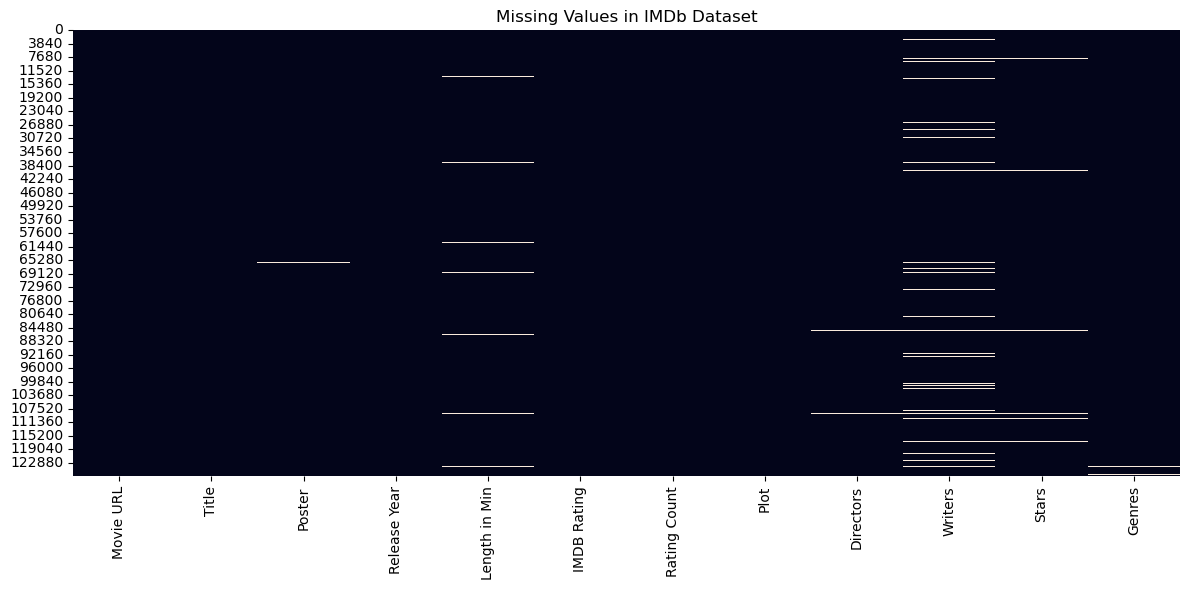

In [10]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values in IMDb Dataset")
plt.tight_layout()
plt.show()

## 10. Check duplicate rows

In [11]:
dup_df = df.duplicated().any()

print("Are there any duplicate rows?", dup_df)
print("Duplicate rows:", df.duplicated().sum())

Are there any duplicate rows? False
Duplicate rows: 0


## 11. Remove duplicate rows

In [12]:
df = df.drop_duplicates().copy()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (126691, 12)


## 12. Check duplicate Movie URLs

In [13]:
duplicate_urls = df["Movie URL"].duplicated().sum()

print("Duplicate Movie URLs:", duplicate_urls)

Duplicate Movie URLs: 0


In [14]:
df = df.drop_duplicates(
    subset=["Movie URL"]
).copy()

print("Dataset Shape:", df.shape)

Dataset Shape: (126691, 12)


## 13. Overall statistics

In [15]:
df.describe(include="all")

,Movie URL,Title,Poster,Release Year,Length in Min,IMDB Rating,Rating Count,Plot,Directors,Writers,Stars,Genres
count,126691,126626,126384,126618.000000,124733.000000,126624.000000,1.266240e+05,126626,125842,119634,125339,126515
unique,126691,118227,126352,NaN,NaN,NaN,NaN,124474,64160,97091,123775,1407
top,https://www.imdb.com/title/tt2787874/?ref_=sr_...,Solo,https://m.media-amazon.com/images/M/MV5BOTg3Mj...,NaN,NaN,NaN,NaN,Add a plot in your language,Michael Curtiz|,Jing Wong|,Penny Singleton|Arthur Lake|Larry Simms,Drama
freq,1,12,4,NaN,NaN,NaN,NaN,2048,85,106,28,16878
mean,NaN,NaN,NaN,1997.355273,100.190046,5.917401,8.803425e+03,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,24.529791,192.061473,1.277181,5.615486e+04,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,1903.000000,17.000000,1.000000,9.900000e+01,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,1984.000000,87.000000,5.200000,1.980000e+02,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2007.000000,95.000000,6.100000,4.650000e+02,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2016.000000,108.000000,6.800000,1.700000e+03,NaN,NaN,NaN,NaN,NaN


## DATA CLEANING

## 14. Create cleaned dataset

In [16]:
df_clean = df.copy()

## 15. Convert numeric columns

In [17]:
numeric_columns = [
    "Release Year",
    "Length in Min",
    "IMDB Rating",
    "Rating Count"
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )

df_clean[numeric_columns].dtypes

Release Year     float64
Length in Min    float64
IMDB Rating      float64
Rating Count     float64
dtype: object

## 16. Check missing values after conversion

In [18]:
print("Missing Values After Conversion:")

print(
    df_clean.isnull().sum()
)

Missing Values After Conversion:
Movie URL           0
Title              65
Poster            307
Release Year       73
Length in Min    1958
IMDB Rating        67
Rating Count       67
Plot               65
Directors         849
Writers          7057
Stars            1352
Genres            176
dtype: int64


## 17. Check IMDb rating range

In [19]:
print(
    "Minimum IMDb Rating:",
    df_clean["IMDB Rating"].min()
)

print(
    "Maximum IMDb Rating:",
    df_clean["IMDB Rating"].max()
)

Minimum IMDb Rating: 1.0
Maximum IMDb Rating: 9.9


## 18. Find invalid IMDb ratings

In [20]:
invalid_ratings = df_clean[
    (df_clean["IMDB Rating"] < 0) |
    (df_clean["IMDB Rating"] > 10)
]

print("Invalid IMDb Ratings:")
print(invalid_ratings)

Invalid IMDb Ratings:
Empty DataFrame
Columns: [Movie URL, Title, Poster, Release Year, Length in Min, IMDB Rating, Rating Count, Plot, Directors, Writers, Stars, Genres]
Index: []


## 19. Check movie runtime

In [21]:
print(
    "Minimum Movie Length:",
    df_clean["Length in Min"].min()
)

print(
    "Maximum Movie Length:",
    df_clean["Length in Min"].max()
)

Minimum Movie Length: 17.0
Maximum Movie Length: 51420.0


## 20. Find runtime outliers

In [22]:
runtime_outliers = df_clean[
    df_clean["Length in Min"] > 500
][
    ["Title", "Length in Min"]
].sort_values(
    "Length in Min",
    ascending=False
)

runtime_outliers.head(15)

,Title,Length in Min
27584,Logistics,51420.0
8519,Ambiancé,43200.0
73041,The Cure for Insomnia,5220.0
76482,The Longest Most Meaningless Movie in the World,2880.0
64783,****,1500.0
117227,The Clock,1440.0
38,The Hazards of Helen,1428.0
50968,Resan,873.0
29702,La flor,808.0
69276,"Out 1, noli me tangere",776.0


## ANALYSIS DATASET

## 21. Create analysis dataset

In [23]:
analysis_df = df_clean.dropna(
    subset=[
        "Title",
        "Release Year",
        "IMDB Rating",
        "Rating Count",
        "Genres"
    ]
).copy()

print("Analysis Dataset Shape:", analysis_df.shape)

Analysis Dataset Shape: (126505, 12)


## 22. Check missing values

In [24]:
print("Missing Values in Analysis Dataset:")
print(analysis_df.isnull().sum())

Missing Values in Analysis Dataset:
Movie URL           0
Title               0
Poster            223
Release Year        0
Length in Min    1852
IMDB Rating         0
Rating Count        0
Plot                0
Directors         776
Writers          6954
Stars            1278
Genres              0
dtype: int64


## RUNTIME CLEANING
## 23. Create runtime dataset

In [25]:
runtime_df = analysis_df[
    (analysis_df["Length in Min"] >= 30) &
    (analysis_df["Length in Min"] <= 300)
].copy()

print("Runtime Analysis Dataset Shape:", runtime_df.shape)

Runtime Analysis Dataset Shape: (124565, 12)


## BASIC IMDb ANALYSIS
## 24. IMDb rating statistics

In [26]:
mean_rating = analysis_df["IMDB Rating"].mean()

median_rating = analysis_df["IMDB Rating"].median()

mode_rating = analysis_df["IMDB Rating"].mode()[0]

print("Mean IMDb Rating:", round(mean_rating, 2))
print("Median IMDb Rating:", round(median_rating, 2))
print("Mode IMDb Rating:", mode_rating)

Mean IMDb Rating: 5.92
Median IMDb Rating: 6.1
Mode IMDb Rating: 6.4


## 25. Summary statistics table

In [27]:
summary_stats = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode"
    ],
    
    "IMDb Rating": [
        round(mean_rating, 2),
        round(median_rating, 2),
        mode_rating
    ]
})

summary_stats

,Statistic,IMDb Rating
0,Mean,5.92
1,Median,6.10
2,Mode,6.40


## TOP RATED MOVIES
## 26. Top-rated movies

In [28]:
# Using a higher vote-count threshold than before (1,000 -> 10,000).
# With only 1,000 votes, obscure/low-visibility titles can post very high
# averages that aren't really comparable to mainstream top-rated films.
top_rated = (
    analysis_df[
        analysis_df["Rating Count"] >= 10000
    ]
    .sort_values(
        "IMDB Rating",
        ascending=False
    )
    .head(15)
)

top_rated[
    [
        "Title",
        "Release Year",
        "IMDB Rating",
        "Rating Count",
        "Genres"
    ]
]


,Title,Release Year,IMDB Rating,Rating Count,Genres
2202,Uruttu Tech,2023.0,9.4,11000.0,Comedy
55976,Gaqceva shoushenkidan,1994.0,9.3,2900000.0,Drama
39770,Natlimama,1972.0,9.2,2000000.0,Crime|Drama
69740,Hababam Sinifi,1975.0,9.2,43000.0,Comedy|Drama
111170,The Silence of Swastika,2021.0,9.2,11000.0,Documentary|History
70221,Ramayana: The Legend of Prince Rama,1993.0,9.2,15000.0,Animation|Action|Adventure
41000,The Godfather Part II,1974.0,9.0,1400000.0,Crime|Drama
23197,12 Angry Men,1957.0,9.0,865000.0,Crime|Drama
123078,12th Fail,2023.0,9.0,113000.0,Biography|Drama
55007,Shindleris sia,1993.0,9.0,1500000.0,Biography|Drama|History


## 27. Top-rated movie chart

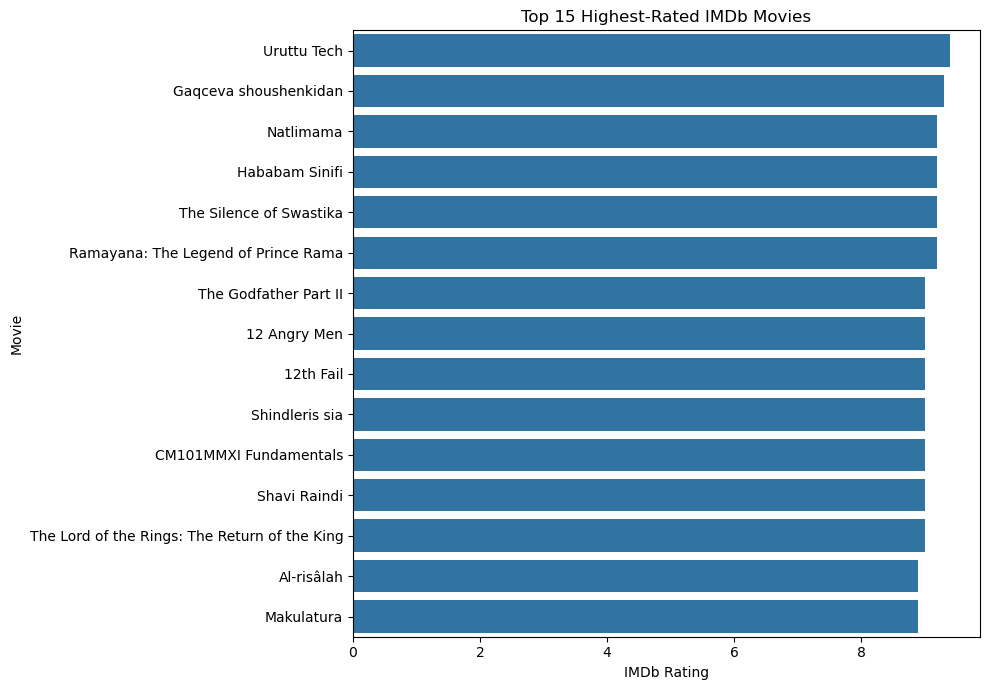

In [29]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_rated,
    x="IMDB Rating",
    y="Title"
)

plt.title(
    "Top 15 Highest-Rated IMDb Movies"
)

plt.xlabel("IMDb Rating")
plt.ylabel("Movie")

plt.tight_layout()
plt.show()

## RATING DISTRIBUTION
## 28. Histogram

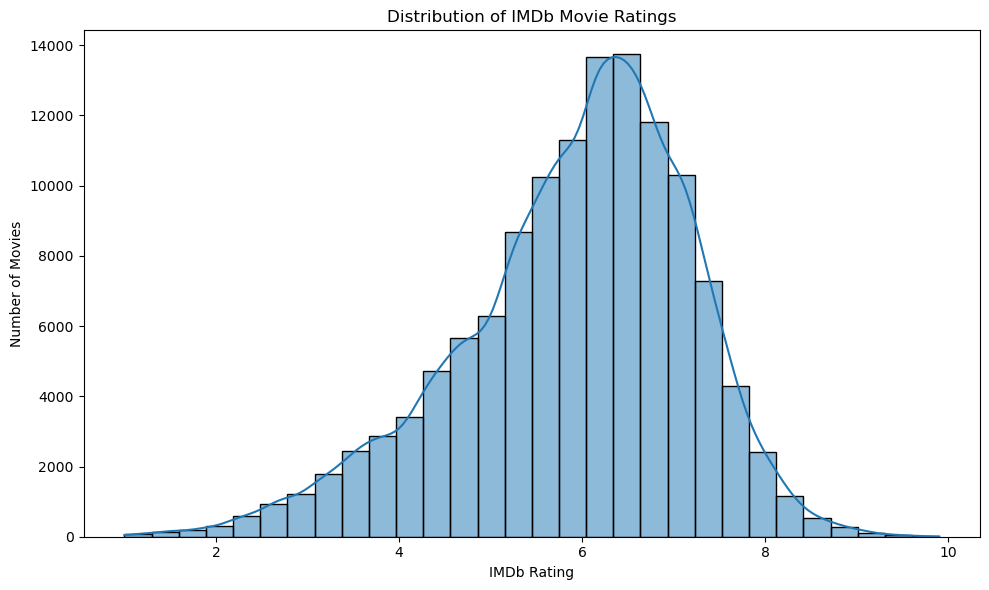

In [30]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=analysis_df,
    x="IMDB Rating",
    bins=30,
    kde=True
)

plt.title(
    "Distribution of IMDb Movie Ratings"
)

plt.xlabel("IMDb Rating")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

## 29. Box plot

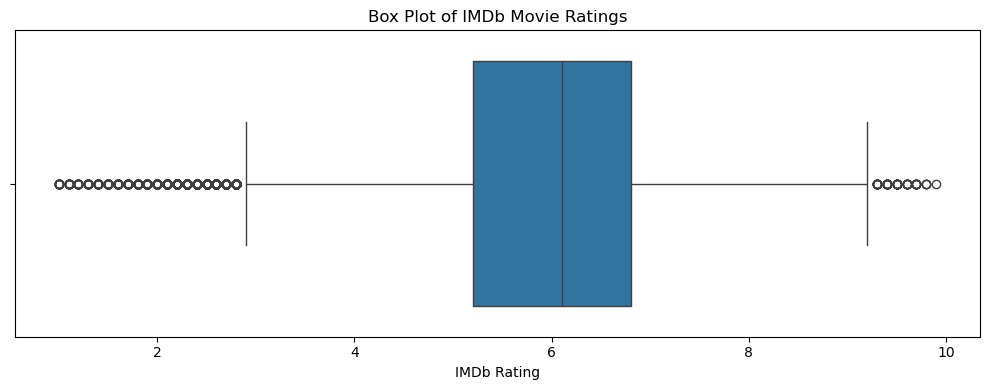

In [31]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=analysis_df["IMDB Rating"]
)

plt.title(
    "Box Plot of IMDb Movie Ratings"
)

plt.xlabel("IMDb Rating")

plt.tight_layout()
plt.show()

## RUNTIME ANALYSIS
## 30. Runtime distribution

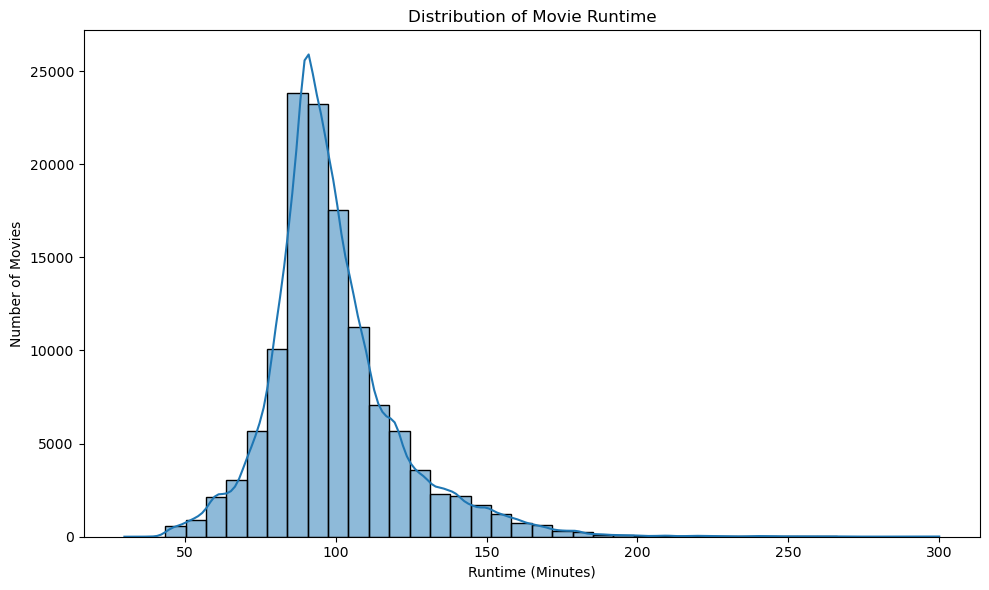

In [32]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=runtime_df,
    x="Length in Min",
    bins=40,
    kde=True
)

plt.title(
    "Distribution of Movie Runtime"
)

plt.xlabel("Runtime (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

## 31. Movies with runtime >= 180 minutes

In [33]:
# Excludes clearly bad/scraped runtime values (e.g. 51,420 min) by capping
# at 500 minutes, which comfortably covers legitimate long films
# (Gone with the Wind ~238 min, Cleopatra ~320 min, Gettysburg ~271 min, etc.)
long_movies = analysis_df[
    (analysis_df["Length in Min"] >= 180) &
    (analysis_df["Length in Min"] <= 500)
][
    [
        "Title",
        "Length in Min",
        "IMDB Rating",
        "Genres"
    ]
].sort_values(
    "Length in Min",
    ascending=False
)

long_movies.head(20)


,Title,Length in Min,IMDB Rating,Genres
27631,Dead Souls,495.0,8.0,Documentary|History
197,Barrabas,489.0,7.6,Crime|Thriller
66182,Empire,485.0,3.7,Documentary
13832,Hele sa hiwagang hapis,485.0,7.5,Adventure|Drama|Fantasy
63431,The Photo-Drama of Creation,480.0,7.0,Documentary|Drama|History
20734,The Works and Days (of Tayoko Shiojiri in the ...,480.0,7.6,Drama
5493,Leviathan: The Story of Hellraiser and Hellbou...,476.0,6.3,Documentary
15812,O.J.: Made in America,467.0,8.9,Documentary|Biography|Crime
99136,Melancholia,450.0,7.4,Drama
42702,"Hitler, ein Film aus Deutschland",442.0,7.5,Biography|Drama


## RATING COUNT ANALYSIS
## 32. Average rating count by year

In [34]:
year_total_rating_count = (
    analysis_df
    .groupby("Release Year")["Rating Count"]
    .sum()
    .sort_values(
        ascending=False
    )
)

year_total_rating_count.head(10)

Release Year
2014.0    45782823.0
2013.0    45288962.0
2012.0    40790710.0
2011.0    40695626.0
2016.0    38770469.0
2010.0    38522570.0
2008.0    37689947.0
2009.0    36730401.0
2015.0    35917230.0
2007.0    35841469.0
Name: Rating Count, dtype: float64

## 34. Rating count by year chart

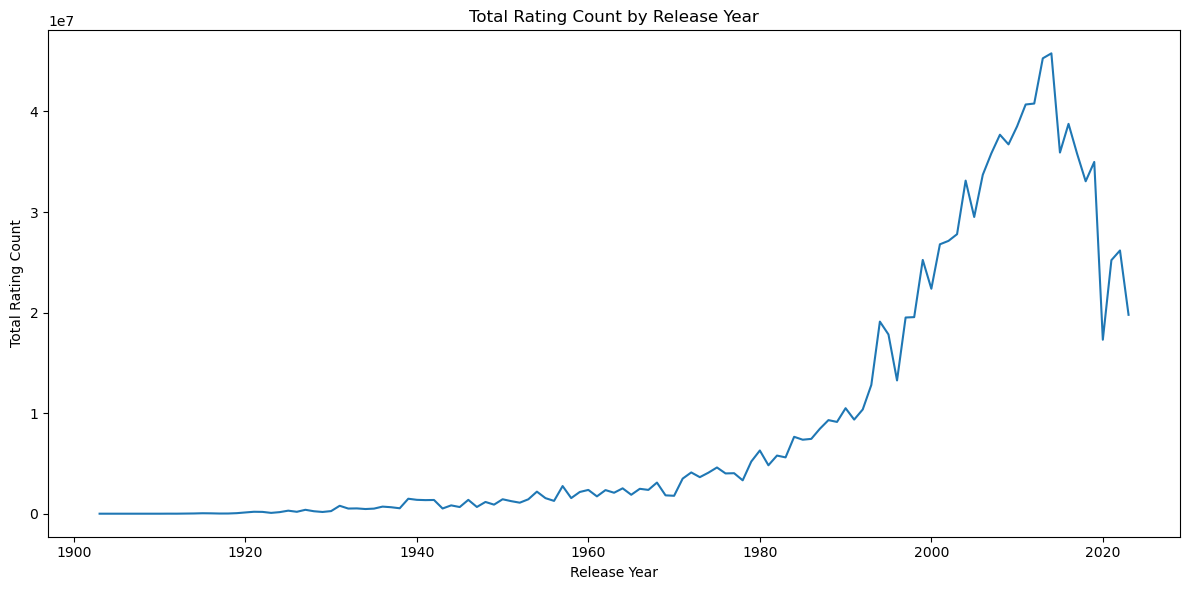

In [35]:
year_rating_chart = (
    analysis_df
    .groupby("Release Year")["Rating Count"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=year_rating_chart,
    x="Release Year",
    y="Rating Count"
)

plt.title(
    "Total Rating Count by Release Year"
)

plt.xlabel("Release Year")
plt.ylabel("Total Rating Count")

plt.tight_layout()
plt.show()

## 34b. Average rating trend by year

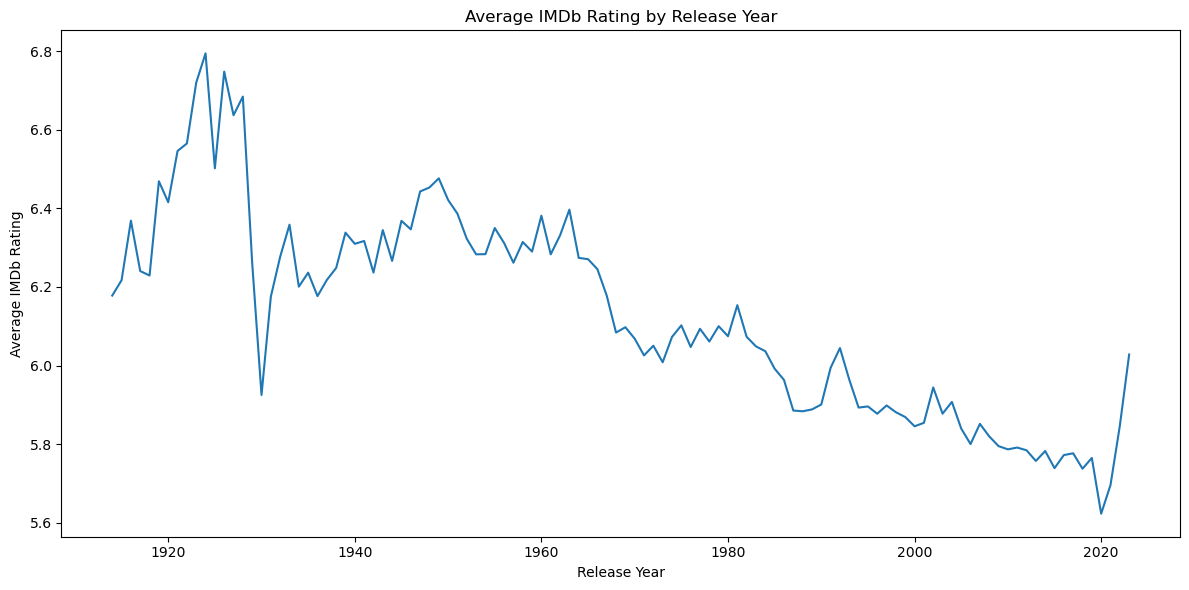

In [36]:
# Total rating COUNT by year (above) mostly reflects how many people were
# online to vote, which skews toward recent years. The average RATING by
# year is more informative about whether movies are actually rated
# higher or lower over time.
rating_trend_by_year = (
    analysis_df
    .groupby("Release Year")["IMDB Rating"]
    .mean()
    .reset_index()
)

# Restrict to years with a reasonable number of movies so early/sparse
# years don't produce noisy averages
year_counts = analysis_df.groupby("Release Year").size()
valid_years = year_counts[year_counts >= 20].index

rating_trend_by_year = rating_trend_by_year[
    rating_trend_by_year["Release Year"].isin(valid_years)
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=rating_trend_by_year,
    x="Release Year",
    y="IMDB Rating"
)

plt.title("Average IMDb Rating by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average IMDb Rating")

plt.tight_layout()
plt.show()


## 34c. Correlation between rating, votes, runtime and year

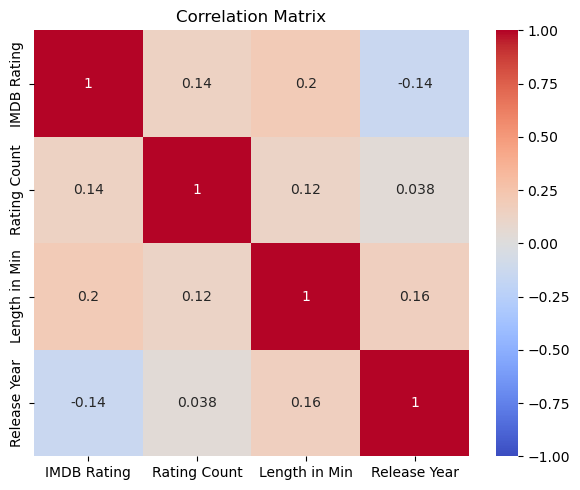

In [37]:
corr_cols = ["IMDB Rating", "Rating Count", "Length in Min", "Release Year"]

# Use runtime_df here instead of analysis_df so the runtime outliers
# (movies logged at 51,420+ minutes) don't distort the correlation
corr_matrix = runtime_df[corr_cols].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## GENRE ANALYSIS
## 35. Split genres

In [38]:
genre_df = analysis_df.copy()

genre_df["Genres"] = (
    genre_df["Genres"]
    .str.split("|")
)

## 36. Explode genres

In [39]:
genre_exploded = genre_df.explode(
    "Genres"
)

genre_exploded[
    [
        "Title",
        "Genres",
        "IMDB Rating"
    ]
].head(10)

,Title,Genres,IMDB Rating
0,Den sorte drøm,Drama,5.8
1,Die Verräterin,Drama,5.9
2,Cleopatra,Drama,5.1
2,Cleopatra,History,5.1
3,L'Inferno,Adventure,7.0
3,L'Inferno,Drama,7.0
3,L'Inferno,Fantasy,7.0
4,Den flyvende cirkus,Drama,6.4
5,From the Manger to the Cross,Biography,5.8
5,From the Manger to the Cross,Drama,5.8


## 37. Genre counts

In [40]:
genre_counts = (
    genre_exploded
    .groupby("Genres")
    .size()
    .sort_values(
        ascending=False
    )
)

genre_counts.head(15)

Genres
Drama          65385
Comedy         39126
Romance        18769
Action         17268
Crime          15682
Thriller       15609
Horror         13570
Documentary    11037
Adventure      10060
Mystery         7674
Family          5710
Fantasy         5161
Biography       4717
Sci-Fi          4567
History         4067
dtype: int64

## 38. Most common genres chart

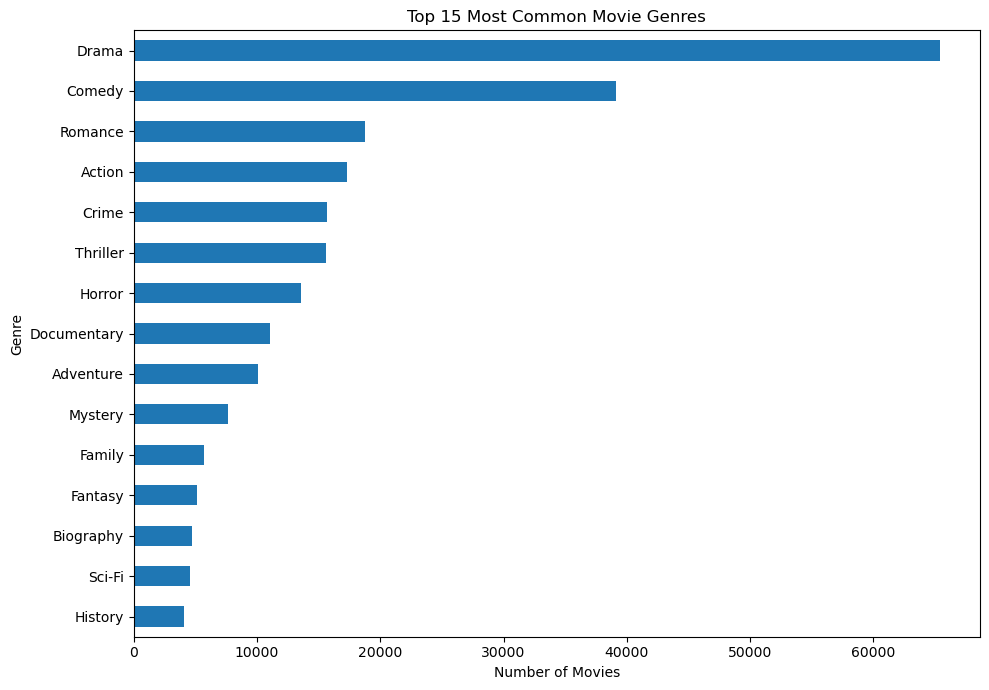

In [41]:
plt.figure(figsize=(10, 7))

genre_counts.head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 15 Most Common Movie Genres"
)

plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

## AVERAGE RATING BY GENRE
## 39. Calculate average rating

In [42]:
genre_rating = (
    genre_exploded
    .groupby("Genres")
    .agg(
        Average_Rating=(
            "IMDB Rating",
            "mean"
        ),
        
        Movie_Count=(
            "IMDB Rating",
            "count"
        )
    )
    .reset_index()
)

## 40. Filter genres

In [43]:
genre_rating = genre_rating[
    genre_rating["Movie_Count"] >= 100
].sort_values(
    "Average_Rating",
    ascending=False
)

genre_rating.head(15)

,Genres,Average_Rating,Movie_Count
16,News,7.117178,163
6,Documentary,7.015593,11037
3,Biography,6.765402,4717
11,History,6.649570,4067
13,Music,6.513267,3407
10,Film-Noir,6.508924,818
24,War,6.421138,3075
21,Sport,6.356300,2000
2,Animation,6.283260,2963
7,Drama,6.160090,65385


## 41. Average rating by genre chart

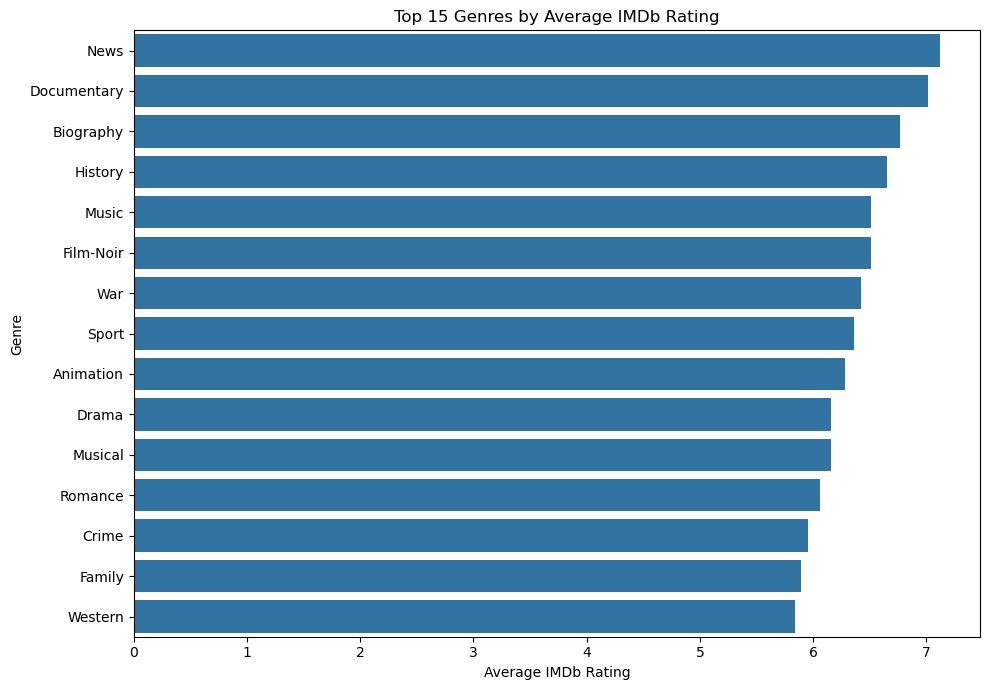

In [44]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=genre_rating.head(15),
    x="Average_Rating",
    y="Genres"
)

plt.title(
    "Top 15 Genres by Average IMDb Rating"
)

plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

## TOP MOVIES TABLE
## 42. Create top movies table

In [45]:
table_df = top_rated[
    [
        "Title",
        "Release Year",
        "IMDB Rating",
        "Rating Count",
        "Genres"
    ]
].copy()

## 43. Format the table

In [46]:
table_df["Release Year"] = (
    table_df["Release Year"]
    .astype(int)
)

table_df["IMDB Rating"] = (
    table_df["IMDB Rating"]
    .map(lambda x: f"{x:.1f}")
)

table_df["Rating Count"] = (
    table_df["Rating Count"]
    .map(lambda x: f"{x:,.0f}")
)

table_df

,Title,Release Year,IMDB Rating,Rating Count,Genres
2202,Uruttu Tech,2023,9.4,"11,000",Comedy
55976,Gaqceva shoushenkidan,1994,9.3,"2,900,000",Drama
39770,Natlimama,1972,9.2,"2,000,000",Crime|Drama
69740,Hababam Sinifi,1975,9.2,"43,000",Comedy|Drama
111170,The Silence of Swastika,2021,9.2,"11,000",Documentary|History
70221,Ramayana: The Legend of Prince Rama,1993,9.2,"15,000",Animation|Action|Adventure
41000,The Godfather Part II,1974,9.0,"1,400,000",Crime|Drama
23197,12 Angry Men,1957,9.0,"865,000",Crime|Drama
123078,12th Fail,2023,9.0,"113,000",Biography|Drama
55007,Shindleris sia,1993,9.0,"1,500,000",Biography|Drama|History


## FINAL DASHBOARD TABLE

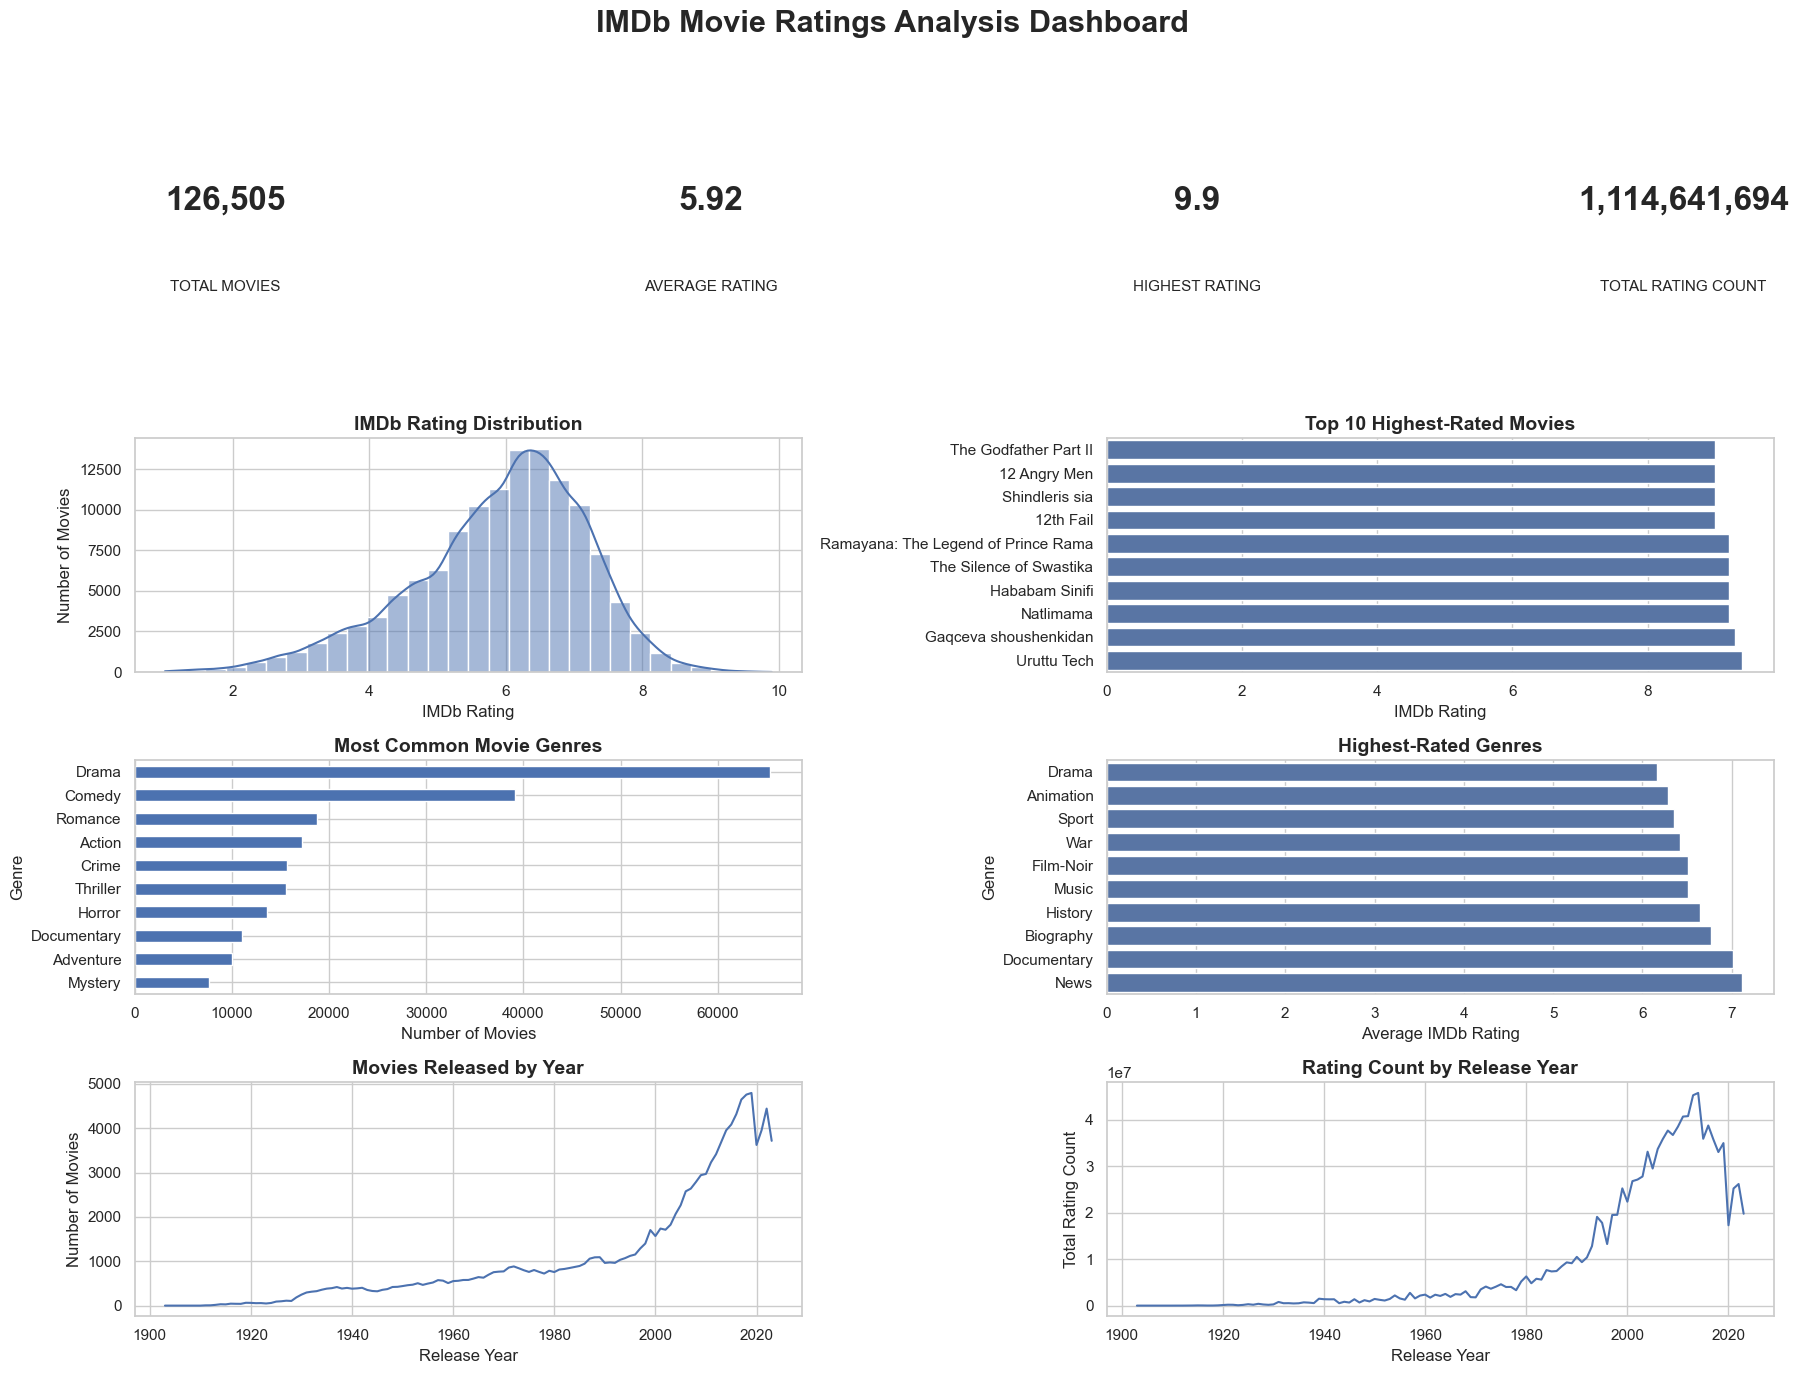

IMDb RATING SUMMARY
--------------------
Total Movies: 126,505
Mean Rating: 5.92
Median Rating: 6.1
Mode Rating: 6.4
Highest Rating: 9.9
Total Rating Count: 1,114,641,694


In [47]:
# ============================================================
# IMDb MOVIE RATINGS ANALYSIS - DASHBOARD
# ============================================================

# analysis_df was already cleaned and numeric-converted earlier in the
# notebook (Sections 15-21), so we reuse it directly instead of
# repeating the same conversion/dropna steps.
dashboard_df = analysis_df.copy()
dashboard_df["Release Year"] = dashboard_df["Release Year"].astype(int)


# ============================================================
# 2. BASIC STATISTICS
# ============================================================

total_movies = len(dashboard_df)

mean_rating = dashboard_df["IMDB Rating"].mean()

median_rating = dashboard_df["IMDB Rating"].median()

mode_rating = dashboard_df["IMDB Rating"].mode()[0]

highest_rating = dashboard_df["IMDB Rating"].max()

total_rating_count = dashboard_df["Rating Count"].sum()


# ============================================================
# 3. TOP 10 MOVIES
# ============================================================

# Same 10,000-vote threshold used earlier, for consistency with the
# top-rated table above
top_movies = (
    dashboard_df[
        dashboard_df["Rating Count"] >= 10000
    ]
    .sort_values(
        "IMDB Rating",
        ascending=False
    )
    .head(10)
)


# ============================================================
# 4. GENRE ANALYSIS
# ============================================================

genre_df = dashboard_df.copy()

genre_df["Genres"] = (
    genre_df["Genres"]
    .astype(str)
    .str.split("|")
)

genre_exploded = genre_df.explode("Genres")


# Most common genres
genre_counts = (
    genre_exploded
    .groupby("Genres")
    .size()
    .sort_values(
        ascending=False
    )
    .head(10)
)


# Average rating by genre
genre_rating = (
    genre_exploded
    .groupby("Genres")
    .agg(
        Average_Rating=("IMDB Rating", "mean"),
        Movie_Count=("IMDB Rating", "count")
    )
    .reset_index()
)

genre_rating = genre_rating[
    genre_rating["Movie_Count"] >= 100
]

genre_rating = (
    genre_rating
    .sort_values(
        "Average_Rating",
        ascending=False
    )
    .head(10)
)


# ============================================================
# 5. YEAR ANALYSIS
# ============================================================

movies_by_year = (
    dashboard_df
    .groupby("Release Year")
    .size()
    .reset_index(
        name="Movie Count"
    )
)


rating_by_year = (
    dashboard_df
    .groupby("Release Year")["Rating Count"]
    .sum()
    .reset_index()
)


# ============================================================
# 6. DASHBOARD STYLE
# ============================================================

sns.set_theme(
    style="whitegrid"
)


# ============================================================
# 7. CREATE DASHBOARD
# ============================================================

fig = plt.figure(
    figsize=(18, 14)
)

fig.suptitle(
    "IMDb Movie Ratings Analysis Dashboard",
    fontsize=22,
    fontweight="bold",
    y=0.98
)


# ============================================================
# KPI 1
# ============================================================

ax1 = plt.subplot2grid(
    (4, 4),
    (0, 0)
)

ax1.axis("off")

ax1.text(
    0.5,
    0.60,
    f"{total_movies:,}",
    ha="center",
    fontsize=24,
    fontweight="bold"
)

ax1.text(
    0.5,
    0.25,
    "TOTAL MOVIES",
    ha="center",
    fontsize=11
)


# ============================================================
# KPI 2
# ============================================================

ax2 = plt.subplot2grid(
    (4, 4),
    (0, 1)
)

ax2.axis("off")

ax2.text(
    0.5,
    0.60,
    f"{mean_rating:.2f}",
    ha="center",
    fontsize=24,
    fontweight="bold"
)

ax2.text(
    0.5,
    0.25,
    "AVERAGE RATING",
    ha="center",
    fontsize=11
)


# ============================================================
# KPI 3
# ============================================================

ax3 = plt.subplot2grid(
    (4, 4),
    (0, 2)
)

ax3.axis("off")

ax3.text(
    0.5,
    0.60,
    f"{highest_rating:.1f}",
    ha="center",
    fontsize=24,
    fontweight="bold"
)

ax3.text(
    0.5,
    0.25,
    "HIGHEST RATING",
    ha="center",
    fontsize=11
)


# ============================================================
# KPI 4
# ============================================================

ax4 = plt.subplot2grid(
    (4, 4),
    (0, 3)
)

ax4.axis("off")

ax4.text(
    0.5,
    0.60,
    f"{total_rating_count:,.0f}",
    ha="center",
    fontsize=24,
    fontweight="bold"
)

ax4.text(
    0.5,
    0.25,
    "TOTAL RATING COUNT",
    ha="center",
    fontsize=11
)


# ============================================================
# CHART 1
# IMDb RATING DISTRIBUTION
# ============================================================

ax5 = plt.subplot2grid(
    (4, 4),
    (1, 0),
    colspan=2
)

sns.histplot(
    data=dashboard_df,
    x="IMDB Rating",
    bins=30,
    kde=True,
    ax=ax5
)

ax5.set_title(
    "IMDb Rating Distribution",
    fontsize=14,
    fontweight="bold"
)

ax5.set_xlabel(
    "IMDb Rating"
)

ax5.set_ylabel(
    "Number of Movies"
)


# ============================================================
# CHART 2
# TOP 10 MOVIES
# ============================================================

ax6 = plt.subplot2grid(
    (4, 4),
    (1, 2),
    colspan=2
)

top_plot = top_movies.sort_values(
    "IMDB Rating"
)

sns.barplot(
    data=top_plot,
    x="IMDB Rating",
    y="Title",
    ax=ax6
)

ax6.set_title(
    "Top 10 Highest-Rated Movies",
    fontsize=14,
    fontweight="bold"
)

ax6.set_xlabel(
    "IMDb Rating"
)

ax6.set_ylabel("")


# ============================================================
# CHART 3
# MOST COMMON GENRES
# ============================================================

ax7 = plt.subplot2grid(
    (4, 4),
    (2, 0),
    colspan=2
)

genre_counts.sort_values().plot(
    kind="barh",
    ax=ax7
)

ax7.set_title(
    "Most Common Movie Genres",
    fontsize=14,
    fontweight="bold"
)

ax7.set_xlabel(
    "Number of Movies"
)

ax7.set_ylabel(
    "Genre"
)


# ============================================================
# CHART 4
# HIGHEST-RATED GENRES
# ============================================================

ax8 = plt.subplot2grid(
    (4, 4),
    (2, 2),
    colspan=2
)

genre_rating_plot = genre_rating.sort_values(
    "Average_Rating"
)

sns.barplot(
    data=genre_rating_plot,
    x="Average_Rating",
    y="Genres",
    ax=ax8
)

ax8.set_title(
    "Highest-Rated Genres",
    fontsize=14,
    fontweight="bold"
)

ax8.set_xlabel(
    "Average IMDb Rating"
)

ax8.set_ylabel(
    "Genre"
)


# ============================================================
# CHART 5
# MOVIES RELEASED BY YEAR
# ============================================================

ax9 = plt.subplot2grid(
    (4, 4),
    (3, 0),
    colspan=2
)

sns.lineplot(
    data=movies_by_year,
    x="Release Year",
    y="Movie Count",
    ax=ax9
)

ax9.set_title(
    "Movies Released by Year",
    fontsize=14,
    fontweight="bold"
)

ax9.set_xlabel(
    "Release Year"
)

ax9.set_ylabel(
    "Number of Movies"
)


# ============================================================
# CHART 6
# RATING COUNT BY YEAR
# ============================================================

ax10 = plt.subplot2grid(
    (4, 4),
    (3, 2),
    colspan=2
)

sns.lineplot(
    data=rating_by_year,
    x="Release Year",
    y="Rating Count",
    ax=ax10
)

ax10.set_title(
    "Rating Count by Release Year",
    fontsize=14,
    fontweight="bold"
)

ax10.set_xlabel(
    "Release Year"
)

ax10.set_ylabel(
    "Total Rating Count"
)


# ============================================================
# 8. DISPLAY DASHBOARD
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()


# ============================================================
# 9. PRINT STATISTICS
# ============================================================

print("IMDb RATING SUMMARY")
print("--------------------")
print("Total Movies:", f"{total_movies:,}")
print("Mean Rating:", round(mean_rating, 2))
print("Median Rating:", round(median_rating, 2))
print("Mode Rating:", mode_rating)
print("Highest Rating:", highest_rating)
print("Total Rating Count:", f"{total_rating_count:,.0f}")


In [1]:
import os
print(os.getcwd())

C:\Users\HP
